In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import corner
import ellc
from ellc import lc

import edmcmc as edm
# import batman

In [2]:
# System parameters
r_1 = 0.04132231404  # units of semi-major axis
r_2 = 0.0011228161490683  # units of semi-major axis
incl = 89.45  # degrees
a = 24.2 # units of solar radii
e = 0.05
f_c = np.sqrt(e) * math.cos(np.deg2rad(-10))
f_s = np.sqrt(e) * math.sin(np.deg2rad(-10))
q = 0.0000291991764706  # mass ratio
shape_1 = "sphere"
shape_2 = "sphere"
period = 9.489  # days
t0 = 2460726.88970225  # start time

In [ ]:
vsini_guess = 1.5  # km/s
lambda1_guess = 45  # degrees

planet_name = "HD-97658-b"
model_name = "updated-1"
csvfile = "../data/HD97658_2025Feb20.csv"
output_dir = "./edmcmc_output/"

df = pd.read_csv(csvfile, comment='#')
for col in ("ccfjdsum", "ccfrvmod", "dvrms"):
    if col not in df.columns:
        raise ValueError(f"Input CSV missing required column: {col}")

time_obs = df['ccfjdsum'].values.astype(float)  # times in days
rv_data = df['ccfrvmod'].values.astype(float)   # observed RV in km/s
rv_err = df['dvrms'].values.astype(float)       # RV uncertainties in km/s

# Compute weighted systemic offset using out-of-transit points and subtract it
i_rad = math.radians(incl)
rsum = (r_1 + r_2)
val = rsum / max(1e-12, math.sin(i_rad))
if val >= 1.0:
    transit_duration_days = 0.2
else:
    transit_duration_days = period / math.pi * val

transit_half_phase = (transit_duration_days / 2.0) / period
phases_for_mask = ((time_obs - t0) / period + 0.5) % 1.0 - 0.5
in_transit_mask = np.abs(phases_for_mask) < transit_half_phase
out_of_transit_mask = ~in_transit_mask

if out_of_transit_mask.sum() < 3:
    out_of_transit_mask = np.ones_like(out_of_transit_mask, dtype=bool)
weights = 1.0 / (rv_err**2)
gamma_weighted = np.sum(weights[out_of_transit_mask] * rv_data[out_of_transit_mask]) / np.sum(weights[out_of_transit_mask])

rv_data = rv_data - gamma_weighted

In [14]:
def loglikelihood(p, time, rv_obs, rv_err):
    vsini_mod, lambda1_mod = p  # free params

    rv_model, _ = ellc.rv(
        time,
        t_zero=t0,
        period=period,
        lambda_1=lambda1_mod,
        radius_1=r_1,
        radius_2=r_2,
        incl=incl,
        a=a,
        f_c=f_c,
        f_s=f_s,
        q=q,
        shape_1=shape_1,
        shape_2=shape_2,
        vsini_1=vsini_mod,
        flux_weighted=True,
        verbose=0
    )

    chi2 = np.sum((rv_obs - rv_model)**2 / (rv_err)**2)
    return -0.5 * chi2


# initial guess and step size
labels = ['v_sini', 'lambda']
p0 = [vsini_guess, lambda1_guess]  # initial params: vsini, lambda1
wid = [0.0001, 0.0001]         # step sizes
parinfo = [
    {   # parameter 0: vsini (km/s)
        'fixed': False,
        'limits': [max(0.0, vsini_guess - 2.5), vsini_guess + 5.0],  # ±0.5 km/s ()>=0)
        'limited': [True, True]
    },
    {   # parameter 1: lambda (degrees)
        'fixed': False,
        'limits': [lambda1_guess - 50.0, lambda1_guess + 50.0],  # ±25 degrees
        'limited': [True, True]
    },
]
ndim = len(p0)

In [15]:
# Run the MCMC
out = edm.edmcmc(
    loglikelihood,
    p0,
    wid,
    args=(time_obs, rv_data, rv_err),  # observed data
    parinfo=parinfo,
    nwalkers=10,  # usually 2-5x number of free params
    nlink=5000,  # number of steps
    nburnin=500,  # number of burn-in steps
    ncores=8,  # number of cores
    quiet=True
    # quiet=False
)

*******************************************************************************************************
True False 1 10 1763662656.0260532 1763662655.9881015 5000
*******************************************************************************************************
True False 2 10 1763662656.0586097 1763662655.9881015 5000
*******************************************************************************************************
True False 3 10 1763662656.0964584 1763662655.9881015 5000
*******************************************************************************************************
True False 4 10 1763662656.1207726 1763662655.9881015 5000
*******************************************************************************************************
True False 5 10 1763662656.1411061 1763662655.9881015 5000
*******************************************************************************************************
True False 6 10 1763662656.1633017 1763662655.9881015 5000
**********************

In [27]:
# Output results
print(np.median(out.flatchains[:,0]), '+/-', np.std(out.flatchains[:,0]), ';    ', np.median(out.flatchains[:,1]), '+/-', np.std(out.flatchains[:,1]))
print(type(out))

# trace plot
fig1, axes1 = plt.subplots(ndim, figsize=(10, 1+2*ndim), sharex=True)
for i in range(ndim):
            ax = axes1[i]
            ax.plot(out.whichlink, out.flatchains[:,i], '.')
            # ax.set_xlim(0, len(samples))
            ax.set_ylabel(labels[i])
            # ax.yaxis.set_label_coords(-0.1, 0.5)
axes1[-1].set_xlabel("Link number")
# fig1_name = output_dir+planet_name+'_'+model_name+'_trace.pdf'
fig1_name = output_dir+planet_name+'_'+model_name+'_trace.pdf'
fig1.savefig(fig1_name)
print('walker trace plot:'+fig1_name)
plt.close(fig1)

# corner plot
fig2 = plt.figure(figsize=(1+3*ndim,1+3*ndim))
fig2 = corner.corner(out.flatchains,labels=labels)
# fig2_name = output_dir+planet_name+'_'+model_name+'_corner.pdf'
fig2_name = output_dir+planet_name+'_'+model_name+'_corner.pdf'
fig2.savefig(fig2_name)
print('corner plot:'+fig2_name)
plt.close(fig2)

# Save best-fitting parameters to CSV
bestfits = {
    'parameter': ['vsin_i', 'lambda'],
    'median': [np.median(out.flatchains[:, 0]), np.median(out.flatchains[:, 1])],
    'std': [np.std(out.flatchains[:, 0]), np.std(out.flatchains[:, 1])]
}

df_best = pd.DataFrame(bestfits)
csv_name = output_dir+planet_name + '_' + model_name + '_bestfit.csv'
df_best.to_csv(csv_name, index=False)

print(f"Best-fitting parameters saved to: {csv_name}")

1.8218500014647343 +/- 0.4789149571055403 ;     44.447131975157646 +/- 16.304150938255336
<class 'edmcmc.mcmcstr'>
walker trace plot:./edmcmc_output/HD-97658-b_updated-1_trace.pdf
corner plot:./edmcmc_output/HD-97658-b_updated-1_corner.pdf
Best-fitting parameters saved to: ./edmcmc_output/HD-97658-b_updated-1_bestfit.csv


<Figure size 700x700 with 0 Axes>

bestmodel plot:./edmcmc_output/HD-97658-b_updated-1_rv_model.pdf


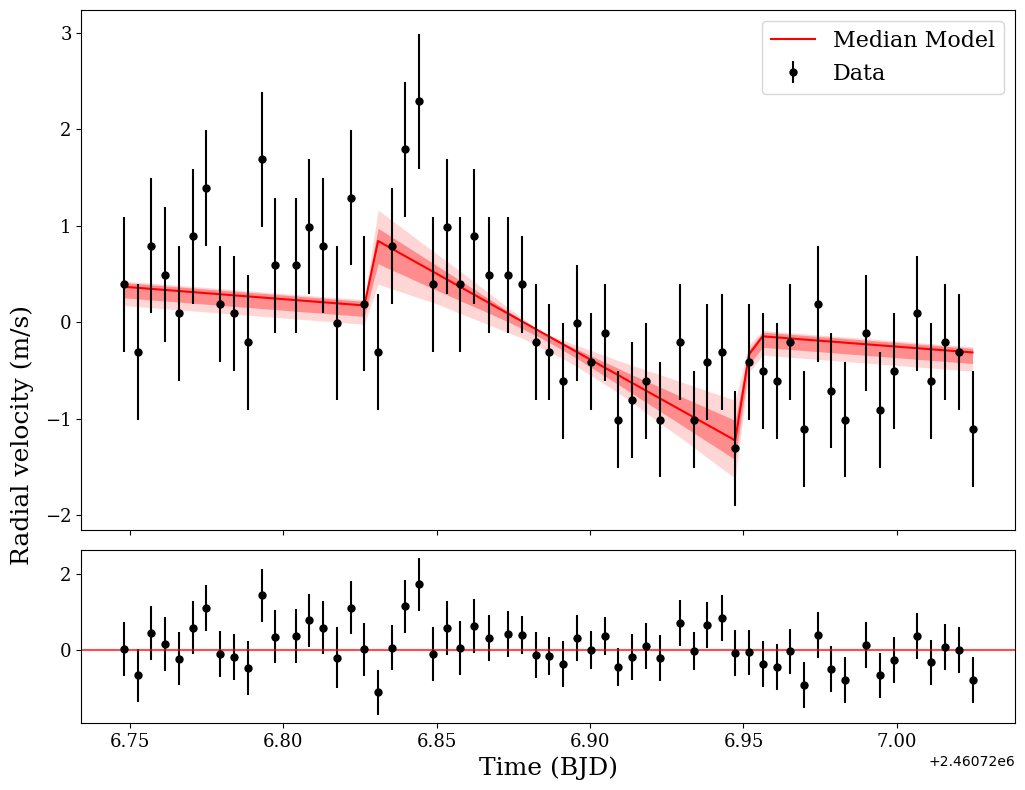

In [34]:
# best-fitting model
best_vsini = np.median(out.flatchains[:, 0])
best_lambda = np.median(out.flatchains[:, 1])

font_choice = 'serif'    # font
label_fontsize = 18      # axis label fontsize
tick_fontsize = 13       # tick label fontsize
legend_fontsize = 16     # legend fontsize
marker_size = 5          # data marker size
model_linewidth = 1.5    # model line width
band_alpha_1sig = 0.34   # alpha for 1-sigma band
band_alpha_2sig = 0.16   # alpha for 2-sigma band

all_samples = out.flatchains
nsamples_total = all_samples.shape[0]
nsamp = min(1000, nsamples_total)
rng = np.random.default_rng(12345)
sel_idx = rng.choice(nsamples_total, size=nsamp, replace=False)

ntime = len(time_obs)
models = np.zeros((nsamp, ntime))

for j, idx in enumerate(sel_idx):
    samp_vsini = all_samples[idx, 0]
    samp_lambda = all_samples[idx, 1]

    rv_call_samp = ellc.rv(
        time_obs,
        t_zero=t0,
        period=period,
        lambda_1=samp_lambda,
        radius_1=r_1,
        radius_2=r_2,
        incl=incl,
        a=a,
        f_c=f_c,
        f_s=f_s,
        q=q,
        shape_1=shape_1,
        shape_2=shape_2,
        vsini_1=samp_vsini,
        flux_weighted=True,
        verbose=0
    )

    star_rv_samp = np.asarray(rv_call_samp[0])
    sys_offset_samp = np.median(rv_data) - np.median(star_rv_samp)
    star_rv_samp += sys_offset_samp

    models[j, :] = star_rv_samp

# Compute percentiles
median_model = np.median(models, axis=0)
p16 = np.percentile(models, 16.0, axis=0)
p84 = np.percentile(models, 84.0, axis=0)
p025 = np.percentile(models, 2.5, axis=0)
p975 = np.percentile(models, 97.5, axis=0)

rv_call_best = ellc.rv(
    time_obs,
    t_zero=t0,
    period=period,
    lambda_1=best_lambda,
    radius_1=r_1,
    radius_2=r_2,
    incl=incl,
    a=a,
    f_c=f_c,
    f_s=f_s,
    q=q,
    shape_1=shape_1,
    shape_2=shape_2,
    vsini_1=best_vsini,
    flux_weighted=True,
    verbose=0
)
star_rv_best = np.asarray(rv_call_best[0])
sys_offset_best = np.median(rv_data) - np.median(star_rv_best)
star_rv_best += sys_offset_best

fig3, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]}
)

ax_top.fill_between(time_obs, p025 * 1e3, p975 * 1e3, color='red', alpha=band_alpha_2sig, linewidth=0.0)#, label='2σ band')
ax_top.fill_between(time_obs, p16 * 1e3, p84 * 1e3, color='red', alpha=band_alpha_1sig, linewidth=0.0)#, label='1σ band')

ax_top.errorbar(
    time_obs,
    rv_data * 1e3,
    yerr=rv_err * 1e3,
    fmt='o',
    ms=marker_size,
    c='k',
    label='Data',
    zorder=5
)
ax_top.plot(
    time_obs,
    star_rv_best * 1e3,
    '-',
    lw=model_linewidth,
    alpha=1.0,
    c='red',
    label='Median Model'
)
ax_top.tick_params(axis='both', labelsize=tick_fontsize)
ax_top.legend(prop={'size': legend_fontsize, 'family': font_choice}, loc='best')

residuals_ms = (rv_data - median_model) * 1e3
ax_bot.errorbar(
    time_obs,
    residuals_ms,
    yerr=rv_err * 1e3,
    fmt='o',
    ms=marker_size,
    c='k',
    label='residuals'
)
ax_bot.axhline(0.0, color='red', linestyle='-', alpha=0.7)
ax_bot.set_xlabel('Time (BJD)', fontsize=label_fontsize, fontname=font_choice)
ax_bot.tick_params(axis='both', labelsize=tick_fontsize)
fig3.text(-0.02, 0.45, 'Radial velocity (m/s)', va='center', rotation='vertical',
          fontsize=label_fontsize, fontname=font_choice)
for ax in (ax_top, ax_bot):
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontname(font_choice)

plt.tight_layout()

fig3_name = output_dir + planet_name + '_' + model_name + '_rv_model.pdf'
fig3.savefig(fig3_name)
print('bestmodel plot:' + fig3_name)
plt.show()
plt.close(fig3)
